<h2 style="color:blue" align="center">Yahoo Stock Market Prediction</h2>

#### Import the necessary libraries

In [535]:
import random as python_random
import time, math 
from tqdm import tqdm
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr
yf.pdr_override()

from sklearn.preprocessing import MinMaxScaler 

import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.callbacks import Callback, CSVLogger 

import warnings
warnings.filterwarnings('ignore')

#### Reserve GPU memory for the execution

In [536]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

1 Physical GPUs, 1 Logical GPUs


#### Load and split the dataset into training and testing set

In [537]:
# Get the stock quote
df = pdr.get_data_yahoo('AAPL', start='2012-01-01', end=datetime.now())
# Show teh data
df

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,14.621429,14.732143,14.607143,14.686786,12.500192,302220800
2012-01-04,14.642857,14.810000,14.617143,14.765714,12.567369,260022000
2012-01-05,14.819643,14.948214,14.738214,14.929643,12.706894,271269600
2012-01-06,14.991786,15.098214,14.972143,15.085714,12.839729,318292800
2012-01-09,15.196429,15.276786,15.048214,15.061786,12.819361,394024400
...,...,...,...,...,...,...
2023-03-24,158.860001,160.339996,157.850006,160.250000,160.250000,59196500
2023-03-27,159.940002,160.770004,157.869995,158.279999,158.279999,52390300
2023-03-28,157.970001,158.490005,155.979996,157.649994,157.649994,45992200


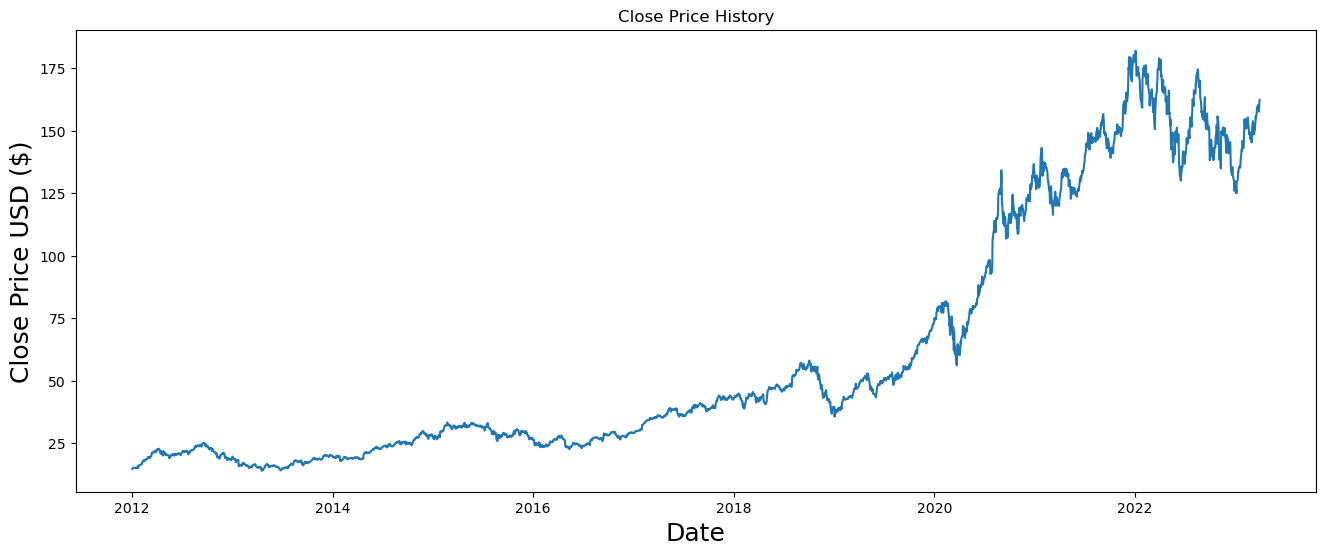

In [538]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [539]:
# Create a new dataframe with only the 'Close column 
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

2688

In [540]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[0.00439887],
       [0.00486851],
       [0.00584391],
       ...,
       [0.85505391],
       [0.8736185 ],
       [0.88307924]])

In [541]:
# Create the training data set 
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0]) 
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

In [542]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

#### Define LSTM model

In [543]:
python_random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)
opti_name = ''

def get_model(): 
    tf.keras.backend.clear_session()
    model = Sequential([ 
        LSTM(64, return_sequences=True, input_shape= (x_train.shape[1], 1)),  
        LSTM(32, return_sequences=False),   
        Dense(25),   
        Dense(1)
    ], name = "LSTM_model")
    
    global opti_name 
    
    # General SGD
    #opti = keras.optimizers.SGD(learning_rate=0.001)
    #opti_name = 'SGD'
    
    # Momentum
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.6)
    #opti_name = 'Momentum'
    
    # Nesterov Accelerated Gradient 
    #opti = keras.optimizers.SGD(learning_rate=0.001, momentum=0.4, nesterov=True)
    #opti_name = 'NAG'
    
    # Adagrad
    #opti = keras.optimizers.Adagrad(learning_rate=0.001) 
    #opti_name = 'AdaGrad' 
    
    # RMSprop 
    #opti = keras.optimizers.RMSprop(learning_rate=0.001)
    #opti_name = 'RMSprop'
    
    # Adadelta
    #opti = keras.optimizers.Adadelta(learning_rate=0.001) 
    #opti_name = 'AdaDelta' 
    
    # Adam
    #opti = keras.optimizers.Adam(learning_rate=0.001) 
    #opti_name = 'Adam'     
    
    # Adamax
    #opti = keras.optimizers.Adamax(learning_rate=0.001) 
    #opti_name = 'AdaMax'
    
    # Nadam
    opti = keras.optimizers.Nadam(learning_rate=0.001) 
    opti_name = 'Nadam'  
    
    model.compile(
        optimizer = opti,
        loss = 'mse'  
    )
    
    return model

#### Custom callbacks

HMS

In [544]:
class CustomCallbackHMS(Callback):  
    initial_weights = 0
    previous_weights = 0
    call_hm = 0 
    temp_model = 0
    r = 1
    t = 100
    
    def __init__(self, mod):
        self.temp_model = mod
        
    def on_train_begin(self, logs=None):
        self.initial_weights = self.temp_model.get_weights() 
        self.initial_weights = np.array(self.initial_weights,dtype=object)
        self.previous_weights = self.initial_weights
        # Harmonic mean based weights calculation
        self.call_hm = np.vectorize(self.apply_hm)  
             
    def on_epoch_end(self, epoch, logs={}):    
        # Minimizing HMS factor every 100 epoch
        if (epoch+1)%self.t == 0:
            self.r = round(self.r *0.9,4)  
        
        num_layers = len(self.temp_model.layers)  
        current_weights = self.temp_model.get_weights()
        current_weights = np.array(current_weights,dtype=object)        

        for i in range(num_layers):  
            # Harmonic mean based weights calculation
            tensor1 = tf.convert_to_tensor(self.previous_weights[i])
            tensor2 = tf.convert_to_tensor(current_weights[i])
            current_weights[i] = self.call_hm(tensor1, tensor2, self.r)   
            
        # Updating the model with new weights
        self.temp_model.set_weights(current_weights.tolist())
        self.previous_weights = current_weights
        
    def apply_hm(self, v1, v2, r): 
        # HMS calculation   
        if v1==0 or v2==0:
            return v2
        elif v1 > v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 - hms
            return v2  
        elif v1 < v2:
            t1 = abs(v1)
            t2 = abs(v2)
            hm = 2*t1*t2/(t1+t2)
            min1 = min(t1,t2)
            hms = abs(hm-min1)*r
            v2 = v2 + hms
            return v2   
        else:
            return v2   

#### Training

Get a model to assign same weights to model with and without HMS

In [545]:
model = get_model() 
weights = model.get_weights() 
num_epochs = 50
Full = x_train.shape[0]
batch_size = 256     # Full / 256 / 64 / 16

To record loss and accuracy in CSV file

In [546]:
generic_file = 'Results/LSTM/'+ opti_name +' optimizer.csv'
hms_file = 'Results/LSTM/'+ opti_name +' HMS optimizer.csv' 
logger_generic_model = CSVLogger(generic_file, append = False, separator=',')
logger_hms_model = CSVLogger(hms_file, append = False, separator=',')

Generic opimizer model

In [547]:
model_wihtout_hms = get_model()
model_wihtout_hms.set_weights(weights) 
st = time.time() 
model_wihtout_hms.fit(x_train, y_train, epochs = num_epochs, verbose=1, callbacks=[logger_generic_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_generic = round(et - st, 4)
print('Execution time:', elapsed_training_time_generic, 'seconds') 

Epoch 1/50
11/11 [==============================] - 1s 6ms/step - loss: 0.0568
Epoch 2/50
11/11 [==============================] - 0s 5ms/step - loss: 0.0015
Epoch 3/50
11/11 [==============================] - 0s 5ms/step - loss: 6.5702e-04
Epoch 4/50
11/11 [==============================] - 0s 5ms/step - loss: 5.1186e-04
Epoch 5/50
11/11 [==============================] - 0s 5ms/step - loss: 5.0345e-04
Epoch 6/50
11/11 [==============================] - 0s 5ms/step - loss: 6.5698e-04
Epoch 7/50
11/11 [==============================] - 0s 5ms/step - loss: 4.4354e-04
Epoch 8/50
11/11 [==============================] - 0s 5ms/step - loss: 4.7739e-04
Epoch 9/50
11/11 [==============================] - 0s 5ms/step - loss: 6.5117e-04
Epoch 10/50
11/11 [==============================] - 0s 5ms/step - loss: 5.7224e-04
Epoch 11/50
11/11 [==============================] - 0s 4ms/step - loss: 0.0016
Epoch 12/50
11/11 [==============================] - 0s 4ms/step - loss: 5.4133e-04
Epoch 13/50
1

HMS-based optimizer model

In [548]:
model_with_hms = get_model()
model_with_hms.set_weights(weights) 
st = time.time()
model_with_hms.fit(x_train, y_train, epochs = num_epochs, verbose=1, callbacks=[CustomCallbackHMS(model_with_hms),logger_hms_model], batch_size=batch_size) 
et = time.time()
elapsed_training_time_hms = round(et - st, 4)
print('Execution time:', elapsed_training_time_hms, 'seconds') 

Epoch 1/50
11/11 [==============================] - 2s 6ms/step - loss: 0.0568
Epoch 2/50
11/11 [==============================] - 0s 6ms/step - loss: 0.0049
Epoch 3/50
11/11 [==============================] - 0s 6ms/step - loss: 6.5836e-04
Epoch 4/50
11/11 [==============================] - 0s 6ms/step - loss: 4.5886e-04
Epoch 5/50
11/11 [==============================] - 0s 6ms/step - loss: 4.1399e-04
Epoch 6/50
11/11 [==============================] - 0s 5ms/step - loss: 4.1224e-04
Epoch 7/50
11/11 [==============================] - 0s 6ms/step - loss: 4.0280e-04
Epoch 8/50
11/11 [==============================] - 0s 6ms/step - loss: 4.0009e-04
Epoch 9/50
11/11 [==============================] - 0s 6ms/step - loss: 4.0083e-04
Epoch 10/50
11/11 [==============================] - 0s 6ms/step - loss: 3.9515e-04
Epoch 11/50
11/11 [==============================] - 0s 6ms/step - loss: 4.0119e-04
Epoch 12/50
11/11 [==============================] - 0s 6ms/step - loss: 4.1629e-04
Epoch 13/

Model summary

In [549]:
model_with_hms.summary()

Model: "LSTM_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            16896     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 25)                825       
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 30,163
Trainable params: 30,163
Non-trainable params: 0
_________________________________________________________________


#### Generic optimizer vs HMS-based optimizer

In [550]:
df1 = pd.read_csv(generic_file)
df2 = pd.read_csv(hms_file)

Loss

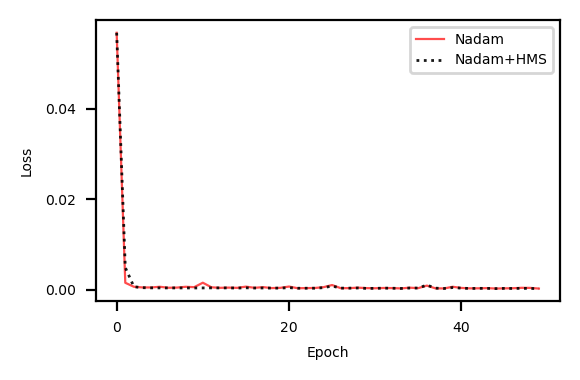

In [551]:
x1 = range(0, df1.shape[0])
x2 = range(0, df2.shape[0])
y1 = df1['loss'] 
y2 = df2['loss']  
plt.figure(figsize = (3,2), dpi = 200)
plt.plot(x1, y1, "r-", label = opti_name, linewidth = 0.8, alpha = 0.7)
plt.plot(x2, y2, "k:", label = opti_name+'+HMS', linewidth = 1, alpha = 0.9) 
plt.ylabel('Loss' , fontdict = {'fontsize':5})
plt.xlabel('Epoch', fontdict = {'fontsize':5}) 
#plt.yscale('log')
#plt.title("Loss", fontdict = {'fontname':'Times New Roman', 'fontsize':8})
plt.xticks(fontsize = 5)
plt.yticks(fontsize = 5)
plt.tight_layout()
plt.legend(prop={'size': 5})
#plt.savefig("graph.png",bbox_inches='tight',dpi=(300)) 
plt.show()

#### Training cost

In [552]:
print(f'Taining cost on {opti_name} = {round(df1.iloc[num_epochs-1].loss, 6)}')
print(f'Taining cost on {opti_name}+HMS = {round(df2.iloc[num_epochs-1].loss, 6)}')

Taining cost on Nadam = 0.00026
Taining cost on Nadam+HMS = 0.000243


#### Testing the model

Generic opimizer model

In [553]:
generic_testing_cost = model_wihtout_hms.evaluate(x_test, y_test)
generic_testing_cost  

5/5 [==============================] - 0s 4ms/step - loss: 21130.0156


21130.015625

HMS-based optimizer model

In [554]:
hms_testing_cost  = model_with_hms.evaluate(x_test, y_test)
hms_testing_cost 

5/5 [==============================] - 0s 2ms/step - loss: 21128.1016


21128.1015625

<h2 style="color:blue" align="center">Training Loss vs Validation Loss</h2>

For generic optimizer

<h2 style="color:blue" align="center">Validation with 10 Random Executions</h2>

In [555]:
num_exe = 10 
loss = [] 
loss_hms = []  

for i in tqdm(np.arange(num_exe)): 
    
        temp_model = get_model()
        temp_weights = temp_model.get_weights() 
    
        # Model without HMS    
        val_model = get_model()
        val_model.set_weights(temp_weights)    
        val_model.fit(x_train, y_train, epochs = num_epochs, verbose=0, batch_size=batch_size) 
        scores = val_model.evaluate(x_test, y_test, verbose = 0)
        loss.append(round(scores, 4)) 

        # Model with HMS
        val_model_hms = get_model()
        val_model_hms.set_weights(temp_weights)     
        val_model_hms.fit(x_train, y_train, epochs = num_epochs, verbose=0, callbacks=[CustomCallbackHMS(val_model_hms)],batch_size=batch_size) 
        scores_hms = val_model_hms.evaluate(x_test, y_test, verbose = 0)
        loss_hms.append(round(scores_hms, 4)) 
        #print('Execution ',i, 'is completed') 

results = pd.DataFrame(list(zip(loss, loss_hms)), columns = [opti_name, opti_name+'+HMS'])
results.to_csv('Results/LSTM/'+opti_name+' summary.csv')

100%|██████████| 10/10 [02:42<00:00, 16.29s/it]


#### Summary on the performance metrics

In [556]:
print('----------------------------------------------') 
print(f'                {opti_name} vs {opti_name}+HMS     ')
print('----------------------------------------------')
print(f'Training set size     : {x_train.shape[0]} samples        ')
print(f'Batch size            : {batch_size} samples      ')
print('----------------------------------------------')
print(f'Training time for single run with {num_epochs} epochs')
print('----------------------------------------------')
print(f'{opti_name}           : {round(elapsed_training_time_generic,4)} seconds') 
print(f'{opti_name}+HMS       : {round(elapsed_training_time_hms,4)} seconds')
print('----------------------------------------------')
print(f'Training cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(df1.iloc[num_epochs-1].loss, 4)}') 
print(f'{opti_name}+HMS       : {round(df2.iloc[num_epochs-1].loss, 4)}')
print('----------------------------------------------')
print(f'Testing cost for single run                 ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(generic_testing_cost, 4)}') 
print(f'{opti_name}+HMS       : {round(hms_testing_cost, 4)}')
print('----------------------------------------------')   
print('''Test set loss on different runs with different 
          weights initilization''')
print('----------------------------------------------')
print(results)
print('----------------------------------------------')
print('            Average loss with test set        ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].mean(),4)} (+- {round(results[results.columns[0]].std(),4)})')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].mean(),4)} (+- {round(results[results.columns[1]].std(),4)})')
print('----------------------------------------------') 
print('       Model that produces minimum loss       ')
print('----------------------------------------------')
print(f'{opti_name}           : {round(results[results.columns[0]].min(),4)}')
print(f'{opti_name}+HMS       : {round(results[results.columns[1]].min(),4)}')
print('----------------------------------------------') 

----------------------------------------------
                Nadam vs Nadam+HMS     
----------------------------------------------
Training set size     : 2628 samples        
Batch size            : 256 samples      
----------------------------------------------
Training time for single run with 50 epochs
----------------------------------------------
Nadam           : 4.3659 seconds
Nadam+HMS       : 6.2206 seconds
----------------------------------------------
Training cost for single run                 
----------------------------------------------
Nadam           : 0.0003
Nadam+HMS       : 0.0002
----------------------------------------------
Testing cost for single run                 
----------------------------------------------
Nadam           : 21130.0156
Nadam+HMS       : 21128.1016
----------------------------------------------
Test set loss on different runs with different 
          weights initilization
----------------------------------------------
        Nadam 

#### Release the GPU memory